In [8]:
import pandas as pd
from pathlib import Path


LOCAL_FOLDER = Path.cwd().parent / "local_folder"
try:
        df = pd.read_csv(LOCAL_FOLDER / 'aggregated_company_data.csv')
except FileNotFoundError:
        print("Błąd: Nie znaleziono pliku aggregated_company_data.csv")

/Users/macbookair/Studia/SEM4/Metody_systemowe_i_decyzyjne/Labolatoria/MSiD_Project/.venv/lib/python3.13/site-packages/skfuzzy/control/fuzzyvariable.py:125: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


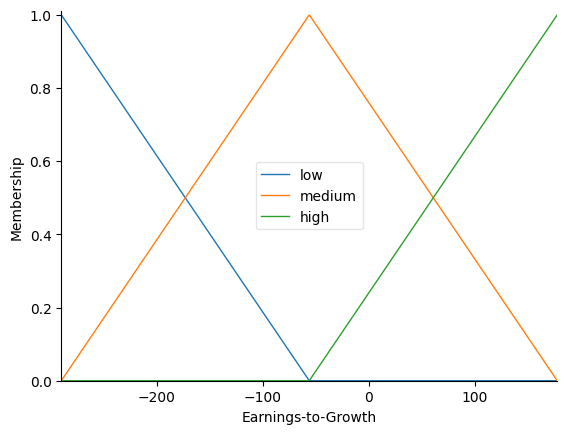

In [9]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

# Parametry przestrzeni rozważań (Universe of Discourse)
RESOLUTION = 1000
MIN_QUANTILE = 0.05
MAX_QUANTILE = 0.95

# 1. EARNINGS-TO-GROWTH (Wycena rynkowa vs tempo wzrostu)
# Uwaga biznesowa: IM MNIEJ TYM LEPIEJ
earnings_to_growth_min_val = df['Earnings-to-Growth'].quantile(MIN_QUANTILE)
earnings_to_growth_max_val = df['Earnings-to-Growth'].quantile(MAX_QUANTILE)
earnings_to_growth_step = (earnings_to_growth_max_val - earnings_to_growth_min_val) / RESOLUTION

earnings_to_growth_array = np.arange(earnings_to_growth_min_val, earnings_to_growth_max_val, earnings_to_growth_step)
etg = ctrl.Antecedent(earnings_to_growth_array, 'Earnings-to-Growth')

# 2. ESG SIGNAL-TO-NOISE (Stabilność i trend rozwoju zrównoważonego)
# Uwaga biznesowa: IM WIĘCEJ TYM LEPIEJ
esg_signal_to_noise_min_val = df['ESG_Signal-to-Noise'].quantile(MIN_QUANTILE)
esg_signal_to_noise_max_val = df['ESG_Signal-to-Noise'].quantile(MAX_QUANTILE)
esg_signal_to_noise_step = (esg_signal_to_noise_max_val - esg_signal_to_noise_min_val) / RESOLUTION

esg_signal_to_noise_array = np.arange(esg_signal_to_noise_min_val, esg_signal_to_noise_max_val, esg_signal_to_noise_step)
esg = ctrl.Antecedent(esg_signal_to_noise_array, 'ESG_Signal-to-Noise')


# 3. PROFIT MARGIN WMA (Rentowność operacyjna i bezpieczeństwo biznesu)
# Uwaga biznesowa: IM WIĘCEJ TYM LEPIEJ
profit_margin_WMA_min_val = df['ProfitMargin_WMA'].quantile(MIN_QUANTILE)
profit_margin_WMA_max_val = df['ProfitMargin_WMA'].quantile(MAX_QUANTILE)
profit_margin_WMA_step = (profit_margin_WMA_max_val - profit_margin_WMA_min_val) / RESOLUTION

profit_margin_WMA_array = np.arange(profit_margin_WMA_min_val, profit_margin_WMA_max_val, profit_margin_WMA_step)
pmw = ctrl.Antecedent(profit_margin_WMA_array, 'ProfitMargin_WMA')

# TARGET SCORE (Wyjście / Consequent) - skala od 0 do 100
score = ctrl.Consequent(np.arange(0, 101, 0.1), 'TARGET_SCORE')

# DEFINIOWANIE FUNKCJI PRZYNALEŻNOŚCI (3 ZBIORY ROZMYTE)
# Low, Medium, High.
names = ['low', 'medium', 'high']

etg.automf(names=names)
esg.automf(names=names)
pmw.automf(names=names)
score.automf(names=names)
etg.view()

### 2. Wizualizacja Funkcji Przynależności (Wykresy)


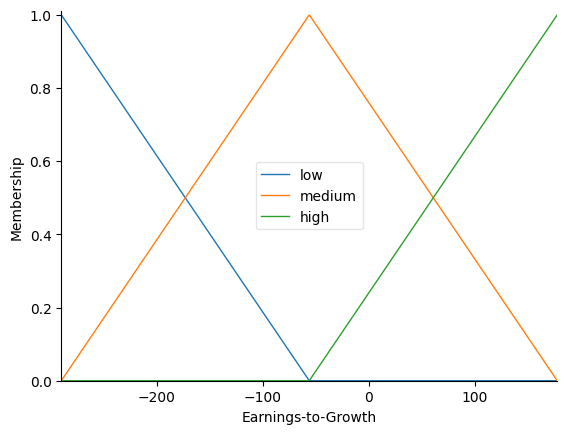

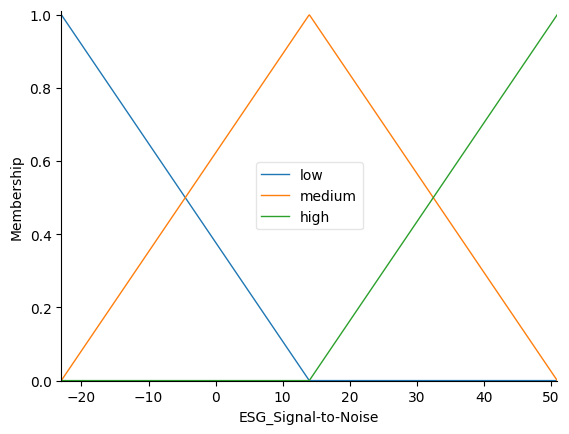

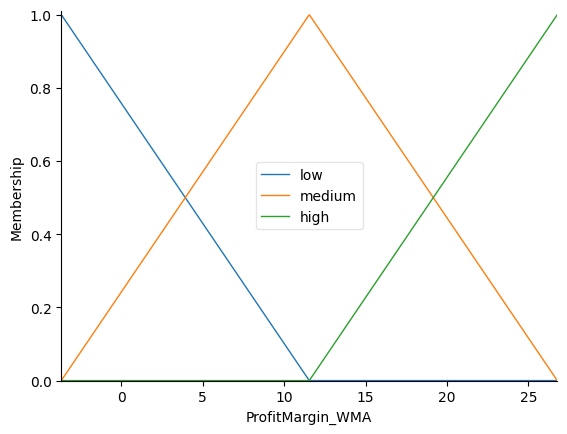

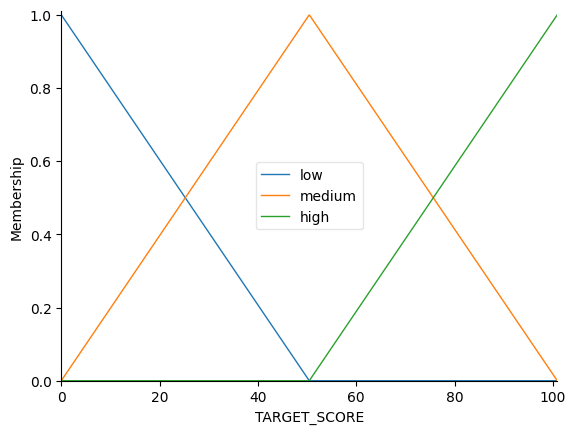

In [10]:
etg.view()
esg.view()
pmw.view()
score.view()

### 3. Definicja Reguł Systemu Rozmytego (Fuzzy Rules)

Baza wiedzy składa się z 27 reguł ($3 \times 3 \times 3$), które pokrywają wszystkie możliwe kombinacje dla naszych trzech zmiennych wejściowych (Earnings-to-Growth, ESG, Profit Margin).

* **Zasada 1:** ETG - im niższe tym lepiej (tania spółka).
* **Zasada 2:** ESG - im wyższe tym lepiej (stabilny trend).
* **Zasada 3:** PMW (Marża) - im wyższa tym lepiej (zyskowny biznes).

Zostały one zgrupowane według wyceny spółki (ETG), aby ułatwić ich czytanie.

In [11]:
# =====================================================================
# GRUPA 1: SPÓŁKI DROGIE (High Earnings-to-Growth - przegrzane akcje)
# Z reguły otrzymują niskie (low) lub średnie (medium) oceny, 
# chyba że ratują się wybitnym ESG i świetną marżą.
# =====================================================================
rule1 = ctrl.Rule(etg['high'] & esg['low'] & pmw['low'], score['low'])
rule2 = ctrl.Rule(etg['high'] & esg['low'] & pmw['medium'], score['low'])
rule3 = ctrl.Rule(etg['high'] & esg['low'] & pmw['high'], score['medium'])

rule4 = ctrl.Rule(etg['high'] & esg['medium'] & pmw['low'], score['low'])
rule5 = ctrl.Rule(etg['high'] & esg['medium'] & pmw['medium'], score['medium'])
rule6 = ctrl.Rule(etg['high'] & esg['medium'] & pmw['high'], score['medium'])

rule7 = ctrl.Rule(etg['high'] & esg['high'] & pmw['low'], score['medium'])
rule8 = ctrl.Rule(etg['high'] & esg['high'] & pmw['medium'], score['medium'])
rule9 = ctrl.Rule(etg['high'] & esg['high'] & pmw['high'], score['high'])

# =====================================================================
# GRUPA 2: SPÓŁKI PRZECIĘTNE (Medium Earnings-to-Growth - uczciwa wycena)
# Oceny zależą mocno od fundamentów i zrównoważonego rozwoju.
# =====================================================================
rule10 = ctrl.Rule(etg['medium'] & esg['low'] & pmw['low'], score['low'])
rule11 = ctrl.Rule(etg['medium'] & esg['low'] & pmw['medium'], score['medium'])
rule12 = ctrl.Rule(etg['medium'] & esg['low'] & pmw['high'], score['medium'])

rule13 = ctrl.Rule(etg['medium'] & esg['medium'] & pmw['low'], score['medium'])
rule14 = ctrl.Rule(etg['medium'] & esg['medium'] & pmw['medium'], score['medium'])
rule15 = ctrl.Rule(etg['medium'] & esg['medium'] & pmw['high'], score['high'])

rule16 = ctrl.Rule(etg['medium'] & esg['high'] & pmw['low'], score['medium'])
rule17 = ctrl.Rule(etg['medium'] & esg['high'] & pmw['medium'], score['high'])
rule18 = ctrl.Rule(etg['medium'] & esg['high'] & pmw['high'], score['high'])

# =====================================================================
# GRUPA 3: SPÓŁKI TANIE (Low Earnings-to-Growth - okazje inwestycyjne)
# Mają ogromny potencjał na wysokie wyniki, jednak niska marża 
# w połączeniu ze słabym ESG może wskazywać na "pułapkę wartości" (value trap).
# =====================================================================
rule19 = ctrl.Rule(etg['low'] & esg['low'] & pmw['low'], score['low'])
rule20 = ctrl.Rule(etg['low'] & esg['low'] & pmw['medium'], score['medium'])
rule21 = ctrl.Rule(etg['low'] & esg['low'] & pmw['high'], score['high'])

rule22 = ctrl.Rule(etg['low'] & esg['medium'] & pmw['low'], score['medium'])
rule23 = ctrl.Rule(etg['low'] & esg['medium'] & pmw['medium'], score['high'])
rule24 = ctrl.Rule(etg['low'] & esg['medium'] & pmw['high'], score['high'])

rule25 = ctrl.Rule(etg['low'] & esg['high'] & pmw['low'], score['medium'])
rule26 = ctrl.Rule(etg['low'] & esg['high'] & pmw['medium'], score['high'])
rule27 = ctrl.Rule(etg['low'] & esg['high'] & pmw['high'], score['high'])

### 4. Budowa Systemu i Symulacja Ocen

Na podstawie zdefiniowanych reguł budujemy `ControlSystem`. Następnie iterujemy po wszystkich firmach w naszym zbiorze danych (`df`), wprowadzamy ich dane wejściowe do systemu rozmytego i zapisujemy wyliczony wynik (`TARGET_SCORE`).

In [ ]:
# Inicjalizacja systemu sterowania rozmytego i symulatora
scoring_ctrl = ctrl.ControlSystem([
    rule1, rule2, rule3, rule4, rule5, rule6, rule7, rule8, rule9,
    rule10, rule11, rule12, rule13, rule14, rule15, rule16, rule17, rule18,
    rule19, rule20, rule21, rule22, rule23, rule24, rule25, rule26, rule27
])
scoring_sim = ctrl.ControlSystemSimulation(scoring_ctrl)

target_scores = []

# Iteracja po wierszach
for index, row in df.iterrows():
    
    # =====================================================================
    # ZABEZPIECZENIE BIZNESOWE (Twarda Reguła / Hard Rule)
    # Sprawdzamy, czy wskaźnik PEG ma w ogóle matematyczny sens
    # =====================================================================
    if row['NetIncome'] <= 0 or row['Risk-AdjustedGrowth'] <= 0:
        # Spółka traci pieniądze lub się zwija. System rozmyty dałby tu zafałszowany wynik.
        # Wymuszamy najniższą możliwą ocenę (0.0).
        target_scores.append(0.0)
        
        # Opcjonalnie: wydrukuj informację o odrzuceniu
        # print(f"[{index + 1}/{len(df)}] Firma: {row['CompanyName']:<20} | ODRZUCONA (Strata/Ujemny wzrost) -> Score: 0.00")
        continue

    # Jeśli spółka jest zyskowna i rośnie, wpuszczamy ją do Fuzzy Logic
    try:
        # Przekazanie wartości atrybutów dla danej firmy
        scoring_sim.input['Earnings-to-Growth'] = row['Earnings-to-Growth']
        scoring_sim.input['ESG_Signal-to-Noise'] = row['ESG_Signal-to-Noise']
        scoring_sim.input['ProfitMargin_WMA'] = row['ProfitMargin_WMA']
        
        # Obliczenie (Defuzyfikacja)
        scoring_sim.compute()
        score_val = scoring_sim.output['TARGET_SCORE']
        
        target_scores.append(round(score_val, 2))
        
        # print(f"[{index + 1}/{len(df)}] Firma: {row['CompanyName']:<20} | Score: {score_val:.2f}")
        
    except Exception as e:
        # Obsługa błędów, np. out of bounds (choć skfuzzy radzi z tym sobie domyślnie ucinając do min/max)
        print(f"!!! Błąd przy firmie {row['CompanyName']}: {e}")
        target_scores.append(np.nan)

# Przypisanie wyników jako nowa kolumna
df['TARGET_SCORE'] = target_scores

# Zapisanie przetworzonych danych z powrotem do CSV
df.to_csv(LOCAL_FOLDER / 'scored_27_rules.csv', index=False)

print("-" * 50)
print(f"Sukces! Symulacja zakończona dla {len(df)} firm.")

# Wyświetlenie 5 najlepiej ocenionych firm w Notebooku
df_sorted = df.sort_values(by='TARGET_SCORE', ascending=False)
display(df_sorted[['CompanyName', 'NetIncome', 'Earnings-to-Growth', 'ESG_Signal-to-Noise', 'ProfitMargin_WMA', 'TARGET_SCORE']].head())

--------------------------------------------------
Sukces! Symulacja zakończona dla 1000 firm.
Firmy ze stratami/ujemnym wzrostem otrzymały ocenę 0. Wyniki zapisane do: scored_company_data.csv


,CompanyName,NetIncome,Earnings-to-Growth,ESG_Signal-to-Noise,ProfitMargin_WMA,TARGET_SCORE
936,Company_937,2154.16,6.33,67.00,26.79,83.14
486,Company_487,7392.57,10.71,53.00,27.63,83.01
377,Company_378,710.80,16.66,79.00,32.54,82.84
594,Company_595,912.71,26.35,51.00,26.61,81.11
81,Company_82,1613.45,23.59,48.33,28.82,75.00
